<a href="https://colab.research.google.com/github/Shri1911/research-project_jpynb/blob/main/Shriram_Final_Submission_GH1052746.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment - Individual Project

Heading - Explanatory Data Analysis Pipeline,
Student Name - Shri Ram Muraleedharan,
Student Number - GH1052746,
Subject - M504C - AI & Applications,
Professor - Muhammad Tanvir Afzal,
https://github.com/Shri1911/research-project_jpynb

Business Context - The dataset used in this project contains transactions from a UK based online retailer that sells gift goods. My objective is to explore the transaction data and identify patterns that could be useful for business decisions. I focus on 8 such scenarios. The analysis is to show what can reasonably be learned from the available transaction records rather than to make claims beyond the dataset.

Data Exploration - Data comprises of large transactions from UCI website, that is downloaded into an Excel sheet.

Observations - some customer id and description values are missing. Negative quantities occur in the data and are associated with cancellations or returns. There are zero or negative unitprices values. These records needs to be considered before calculating sales because they can distort the results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

print(df.info())
print("\nMissing Values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


I have cleaned the data so that sales calculations were based on  usable customer purchases. Rows without a customer ID were removed because they cannot be linked to an identified customer. I also excluded records where quantity or unit price was zero or negative. I created Total sales and extracted the hour and month from InvoiceDate. one limitation of this approach is that removing cancellations means that this analysis does not investigate returns or cancellation behaviour.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
orders = pd.read_excel(url)
valid_orders = orders.dropna(subset=['CustomerID']).query('Quantity > 0 and UnitPrice > 0').copy()
valid_orders['TotalSales'] = valid_orders['Quantity'] * valid_orders['UnitPrice']
valid_orders['InvoiceHour'] = valid_orders['InvoiceDate'].dt.hour
valid_orders['InvoiceMonth'] = valid_orders['InvoiceDate'].dt.to_period('M')

print (f"Data shape after cleaning: {valid_orders.shape}")


Data shape after cleaning: (397884, 11)


Explanatory Data Analysis - I wanted to find outh when customers places the most orders. If purchasing activity is concentrated at certain hours, the business could use that information when palnning the timing of promotions. The transaction data does not contain advertising impressions or conversions, so this analysis can suggest a time window but cannot prove the best advertising time.

Results and Interpretation - The hourly order count reached it's peak time around 12 PM midday. This shows that this time is an important purchasing period in this dataset.

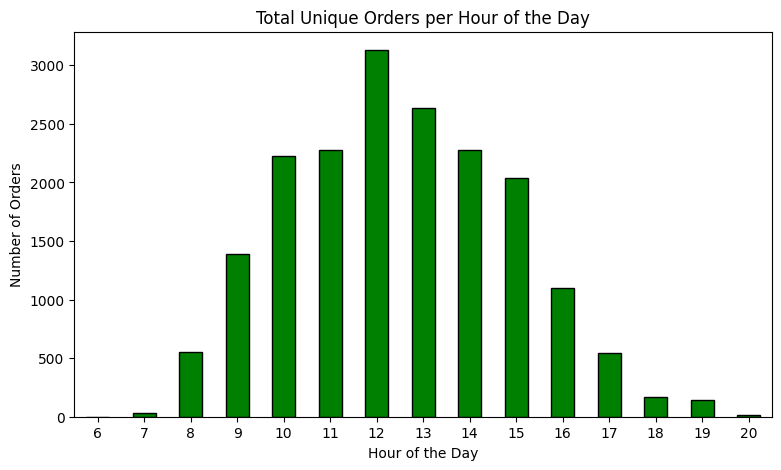

The maximum purchasing hour is 12:00.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url =  "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df_plot = pd.read_excel(url)

df_plot = df_plot.dropna(subset=['CustomerID']).copy()
df_plot = df_plot[(df_plot['Quantity']>0) & (df_plot['UnitPrice']>0)]
df_plot['TotalSales'] = df_plot['Quantity'] * df_plot['UnitPrice']
df_plot['InvoiceHour'] = df_plot['InvoiceDate'].dt.hour

hourly_sales = df_plot.groupby('InvoiceHour')['InvoiceNo'].nunique()
rush_hours = hourly_sales.idxmax()
plt.figure(figsize=(9,5))
hourly_sales.plot(kind='bar', color='green', edgecolor='black')
plt.title('Total Unique Orders per Hour of the Day')
plt.xlabel ('Hour of the Day')
plt.ylabel ('Number of Orders')
plt.xticks (rotation=0)
plt.show()

print(f"The maximum purchasing hour is {rush_hours}:00.")

Geographical Markets outside the UK that generate highest Revenue - I compared which international markets contribute the most sales. This can help business identify markets that deserve closer attention.



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)
df_intl = df[df['Country'] != 'United Kingdom'].copy()
df_intl = df_intl.dropna(subset=['CustomerID'])
df_intl = df_intl[(df_intl['Quantity']>0) & (df_intl['UnitPrice']>0)]
df_intl['TotalSales'] = df_intl['Quantity'] * df_intl['UnitPrice']

top_markets = df_intl.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(6)
print("Big 6 International Markets By Revenue:")
print(top_markets)

Big 6 International Markets By Revenue:
Country
Netherlands    285446.34
EIRE           265545.90
Germany        228867.14
France         209024.05
Australia      138521.31
Spain           61577.11
Name: TotalSales, dtype: float64


Results and Interpretation - The Netherlands, EIRE(Ireland) and Germany appear among the leading international markets for total revenue. This shows that these European Markets are comercially important in the dataset. The company should also consider costs, margins before increasing marketing or shipping investment.

Monthly revenue helps show whether demand changes during the year. Recognising seasonal patterns can support stock and operational planning.

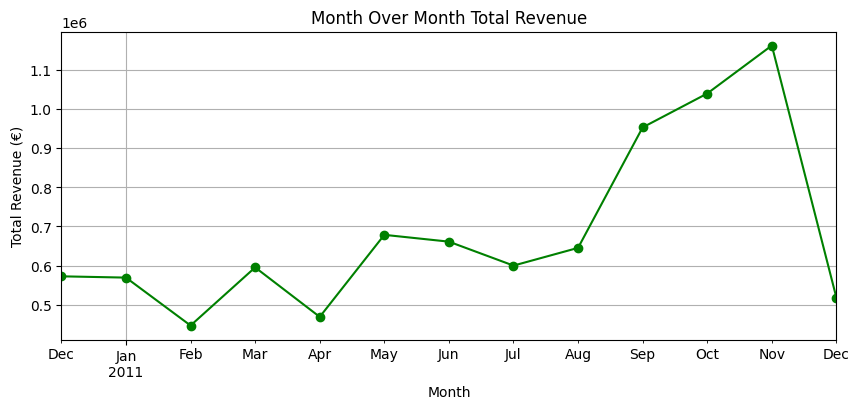

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df_plot = pd.read_excel(url)

df_plot = df_plot.dropna(subset=['CustomerID']).copy()
df_plot = df_plot[(df_plot['Quantity']>0) & (df_plot['UnitPrice']>0)]
df_plot['TotalSales'] = df_plot['Quantity'] * df_plot['UnitPrice']
df_plot['InvoiceMonth'] = df_plot['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_plot.groupby('InvoiceMonth')['TotalSales'].sum()
plt.figure(figsize=(10,4))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Month Over Month Total Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue (€)')
plt.grid(True)
plt.show()

Results and Interpretation - The monthly increase shows a clear increase during the later part of the year, with a strong rise from September to November.

Top 7 most valuable customers based on total monetary spend. Just a very few customers account for a higher proportion of revenue. Therefore it is important to retain them.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df_plot = pd.read_excel(url)
df_plot = df_plot.dropna(subset=['CustomerID']).copy()
df_plot = df_plot[(df_plot['Quantity']>0) & (df_plot['UnitPrice']>0)]
df_plot['TotalSales'] = df_plot['Quantity'] * df_plot['UnitPrice']

valuable_clients = df_plot.groupby('CustomerID')['TotalSales'].sum().sort_values(ascending=False).head(7)
print("7 most valuable clients")
for customer_id, spend in valuable_clients.items():
    print(f"Customer{int(customer_id)}: €{spend:.2f}")

7 most valuable clients
Customer14646: €280206.02
Customer18102: €259657.30
Customer17450: €194550.79
Customer16446: €168472.50
Customer14911: €143825.06
Customer12415: €124914.53
Customer14156: €117379.63


Results and interpretation - Grouping transactions by customer id and adding total sales identifies the seven customers with the highest recorded spent during the dataset period.These accounts could be considered for retention activity.

I compared top 6 products by revenue to identify items that make a large contribution to sales. It can be useful for inventory planning and for understanding which products are commercially important




.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df_plot = pd.read_excel(url)
df_plot = df_plot.dropna(subset=['CustomerID']).copy()
df_plot = df_plot[(df_plot['Quantity']>0) & (df_plot['UnitPrice']>0)]
df_plot['TotalSales'] = df_plot['Quantity'] * df_plot['UnitPrice']

highest_products = df_plot.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(6)
print("Highest Revenue Making Products:")
print(highest_products)

Highest Revenue Making Products:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
Name: TotalSales, dtype: float64


Result and Interpretation - The rankings above show that 6 highest revenue generating products. The company must be able to pay close attention to the availability of the high revenue products.

Regular customers - I identified how many unique invoices each customer has and then calculate the percentage of customers with more than one order

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df_plot = pd.read_excel(url)
df_plot = df_plot.dropna(subset=['CustomerID']).copy()
df_plot = df_plot[(df_plot['Quantity']>0) & (df_plot['UnitPrice']>0)]

order_counts = df_plot.groupby ('CustomerID') ['InvoiceNo'] .nunique()
regular_customers = (order_counts > 1).sum()
total_customers = order_counts.count()
regular_rate = (regular_customers/total_customers) * 100
print(f"Regular Customer percentage:{regular_rate:.2f}%")

Regular Customer percentage:65.58%


Result - The calculation shows that more than 65% of the identified buyers place orders often during the period covered by the dataset. This indicates a substantial level of repeat purchasing among
customers with a CustomerID.

Final discussion and conclusion - Strengths and Limitations of the EDA: The primary strength of this explanatory data analysis pipeline is its concrete grounding in transactional reality; every design decision and insight is derived from actual purchasing behavior. The Python/Pandas operations successfully automated the extraction of time-series trends, financial KPIs, and associative product behaviors. However, a limitation of this dataset is the lack of customer demographic data, which restricts our ability to build deeper psychographic segments. Additionally, removing all cancelled transactions cleans the revenue metrics but ignores the potential operational insights hidden in return rates.
Business Implications and Recommendations:
1. Marketing Timing: Launch daily ad campaigns between 10:00 AM and 11:30 AM to intercept the 12:00 PM purchasing peak.
2. Global Expansion: Consolidate international expansion resources into the Netherlands and Ireland, establishing higher free-shipping thresholds to match their large Average Order Values.
3. Inventory Phasing: Warehouse capacity and top-selling "cash cow" procurement must be scaled aggressively starting in August to accommodate the Q4 holiday spike.
4. Cross-Selling Automation: Implement the identified top product pairs as bundled SKUs or automated recommendations on the front-end application to drive higher cart values

References - Dataset URL: https://archive.ics.uci.edu/ml/datasets/Online+Retail

Link - https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"